In [2]:
# Imports
## Standard
import numpy as np
import matplotlib.pyplot as plt

## Utils
import run_fair
import utils_optimization
import utils_ML

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

### Stage 1: Load datasets

In [37]:
# Required variables
AGENTS = ['CO2','CH4','Sulfur']
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
FS = 1

# Generate ScenarioMIP for CMIP7 scenarios
emis_dict_tier1, emis_dict_tier2 = run_fair.load_scenarioMIP_CMIP7(AGENTS)
scenarios_tier1, scenarios_tier2 = list(emis_dict_tier1.keys()), list(emis_dict_tier2.keys())
delT_dict_tier1 = run_fair.get_delT(emis_dict_tier1, scenarios_tier1, AGENTS, MIP='ScenarioMIP_tier1')
delT_dict_tier2 = run_fair.get_delT(emis_dict_tier2, scenarios_tier2, AGENTS, MIP='ScenarioMIP_tier2')

# Generate DECK scenarios (includes custom scenarios e.g. abrupt-4xCH4)
emis_dict_DECK = run_fair.load_DECK_CMIP7(AGENTS)
scenarios_DECK = list(emis_dict_DECK.keys())
delT_dict_DECK = run_fair.get_delT(emis_dict_DECK, scenarios_DECK, AGENTS, MIP='DECK')

# Generate GeoMIP scenarios
emis_dict_geoMIP = run_fair.load_geoMIP_CMIP6(AGENTS, emis_dict_tier1)
scenarios_geoMIP = list(emis_dict_geoMIP.keys())
delT_dict_geoMIP = run_fair.get_delT(emis_dict_geoMIP, scenarios_geoMIP, AGENTS, MIP='GeoMIP')

# Generate CS3 scenarios
emis_dict_CS3 = run_fair.load_CS3(AGENTS, emis_dict_tier1)
scenarios_CS3 = list(emis_dict_CS3.keys())
delT_dict_CS3 = run_fair.get_delT(emis_dict_CS3, scenarios_CS3, AGENTS, MIP='CS3')

# Create tier1 series
series_tier1 = []
for scen in scenarios_tier1:
  if scen != 'historical':
    needs_history = True
  else:
    needs_history = False
  series_tier1.append((emis_dict_tier1[scen], delT_dict_tier1[scen], needs_history))

# Create tier2 series
series_tier2 = []
for scen in scenarios_tier2:
  if scen != 'historical':
    needs_history = True
  else:
    needs_history = False
  series_tier2.append((emis_dict_tier2[scen], delT_dict_tier2[scen], needs_history))

# Create DECK series
series_DECK = []
scenarios_DECK_subset = []
for scen in scenarios_DECK:
  if scen == 'historical':
    continue
  for a in AGENTS:
    if a not in scen:
      continue
    else:
      scenarios_DECK_subset.append(scen)
      series_DECK.append((emis_dict_DECK[scen], delT_dict_DECK[scen], False))

# Create validation series
series_valid = series_tier1.copy() + series_DECK.copy()
scenarios_valid = scenarios_tier1.copy() + scenarios_DECK_subset.copy()
delT_dict_valid = delT_dict_tier1.copy() | delT_dict_DECK.copy()

# Create GeoMIP series
series_geoMIP = []
for scen in scenarios_geoMIP:
  if scen == 'historical':
    continue
  if scen != 'historical':
    series_geoMIP.append((emis_dict_geoMIP[scen], delT_dict_geoMIP[scen], True))
  else:
    series_geoMIP.append((emis_dict_geoMIP[scen], delT_dict_geoMIP[scen], False))

# Create CS3 series
series_CS3 = []
for scen in scenarios_CS3:
  if scen == 'historical':
    continue
  if scen != 'historical':
    series_CS3.append((emis_dict_CS3[scen], delT_dict_CS3[scen], True))
  else:
    series_CS3.append((emis_dict_CS3[scen], delT_dict_CS3[scen], False))

scenarios_all = scenarios_tier1 + scenarios_tier2 + scenarios_DECK_subset + scenarios_geoMIP + scenarios_CS3
series_all = series_tier1 + series_tier2 + series_DECK + series_geoMIP + series_CS3

### Stage 2: Experiment configuration

In [39]:
eps = 1e-7
use_white_noise = False
MEAN_FUNC_NAME = 'delayed_sinusoid' # 'const', 'sinsuoid', 'multi_sine'...
loss_metric = 'mean'  # 'max', 'mean', or 'median'

CONFIG = {
  "CHOSEN_MEAN_FUNCTION": MEAN_FUNC_NAME,
  "USE_WHITE_NOISE": use_white_noise,
  "N_INNER_SAMPLES": 10 if use_white_noise else 1,
  "N_ENSEMBLE_MODELS": 1,
  "NOISE_PARAM_SPACE": {
    "sigma": (10.0, 75.0),
    "f_low": (0.01, 0.1 - eps),
    "f_high": (0.1 + eps, 0.5 - eps),
  },
}

# Define output paths
VALIDATION_NAME = "tier1+DECK"
base_filename = utils_optimization.generate_experiment_filename(
  mean_func_name=MEAN_FUNC_NAME,
  use_white_noise=CONFIG["USE_WHITE_NOISE"],
  n_inner=CONFIG["N_INNER_SAMPLES"],
  n_ensemble=CONFIG["N_ENSEMBLE_MODELS"],
  agents=AGENTS,
  validation_name=VALIDATION_NAME,
  loss=loss_metric
)
LHS_RESULTS_FILE = f'data/Optimization/lhs_{base_filename}.csv'
BO_STATE_FILE = f'data/Optimization/bo_{base_filename}.json'

### Stage 3: Exploration using Latin hypercube sampling

In [41]:
pbounds, mean_func = utils_optimization.build_pbounds(CONFIG, AGENTS, n_steps)
print(f"Optimization started for '{MEAN_FUNC_NAME}' with {len(pbounds)} parameters.")

# --- Step 2: Initialize the Black-Box Function ---
# The wrapper holds all static arguments, modules, and data.
black_box_func = utils_optimization.OptimizationWrapper(
  CONFIG=CONFIG,
  mean_func=mean_func,
  agents=AGENTS,
  n_steps=n_steps,
  FS=FS,
  start=start,
  stop=stop,
  scenarios_valid=scenarios_valid,
  series_valid=series_valid,
  loss_metric=loss_metric
)

# --- Step 3: Run Latin hypercube sampling
N_LHS_SAMPLES = 480
lhs_results = utils_optimization.run_lhs_phase(
  black_box_func,
  pbounds,
  n_samples=N_LHS_SAMPLES,
  csv_path=LHS_RESULTS_FILE
)

Optimization started for 'delayed_sinusoid' with 9 parameters.
Checking for existing LHS results at data/Optimization/lhs_mean-delayed_sinusoid_noise-off_inner-1_ensemble-1_agents-CH4+CO2+Sulfur_valid-tier1+DECK_loss-mean.csv...
Found and loaded 240 existing LHS results.
Target is 480, found 240. Running 240 new LHS evaluations...
Running LHS sample 241/480...
Running LHS sample 242/480...
Running LHS sample 243/480...
Running LHS sample 244/480...
Running LHS sample 245/480...
Running LHS sample 246/480...
Running LHS sample 247/480...
Running LHS sample 248/480...
Running LHS sample 249/480...
Running LHS sample 250/480...
Running LHS sample 251/480...
Running LHS sample 252/480...
Running LHS sample 253/480...
Running LHS sample 254/480...
Running LHS sample 255/480...
Running LHS sample 256/480...
Running LHS sample 257/480...
Running LHS sample 258/480...
Running LHS sample 259/480...
Running LHS sample 260/480...
Running LHS sample 261/480...
Running LHS sample 262/480...
Running

### Stage 4: Bayesian optimization

In [42]:
# --- Step 4: Setup BO Optimizer (Call is updated) ---
optimizer = utils_optimization.setup_bo_optimizer(
  black_box_func,
  pbounds,
  lhs_results,
  bo_state_file=BO_STATE_FILE,
  random_state=42
)

# --- Step 5: Run BO Phase (Call is updated) ---
N_BO_ITERATIONS = 40
utils_optimization.run_bo_iterations(
  optimizer,
  n_iter=N_BO_ITERATIONS,
  bo_state_file=BO_STATE_FILE
)

# --- Step 6: (No change) ---
print("\n--- FINAL OPTIMIZATION RESULTS ---")
print(optimizer.max)

No state file found. Registering 480 LHS points...
| 232       | -0.688362 | 164.21828 | 0.0085199 | 35.624713 | 576.34989 | 0.0007699 | 159.88310 | 81.526196 | 0.0038109 | 58.829905 |
Optimizer setup complete. Loaded 480 LHS points and 0 previous BO points.
Running 40 new Bayesian Optimization iterations...
|   iter    |  target   | m_para... | m_para... | m_para... | m_para... | m_para... | m_para... | m_para... | m_para... | m_para... |
-------------------------------------------------------------------------------------------------------------------------------------

Saving updated optimizer state to: data/Optimization/bo_mean-delayed_sinusoid_noise-off_inner-1_ensemble-1_agents-CH4+CO2+Sulfur_valid-tier1+DECK_loss-mean.json

Optimization Complete!
--- Best Result ---
{'target': np.float64(-0.688362834372707), 'params': {'m_param_amplitude_CO2': np.float64(164.2182831165954), 'm_param_frequency_CO2': np.float64(0.0085199064239827), 'm_param_t_start_CO2': np.float64(35.624713389711

### Stage 5: Evaluation

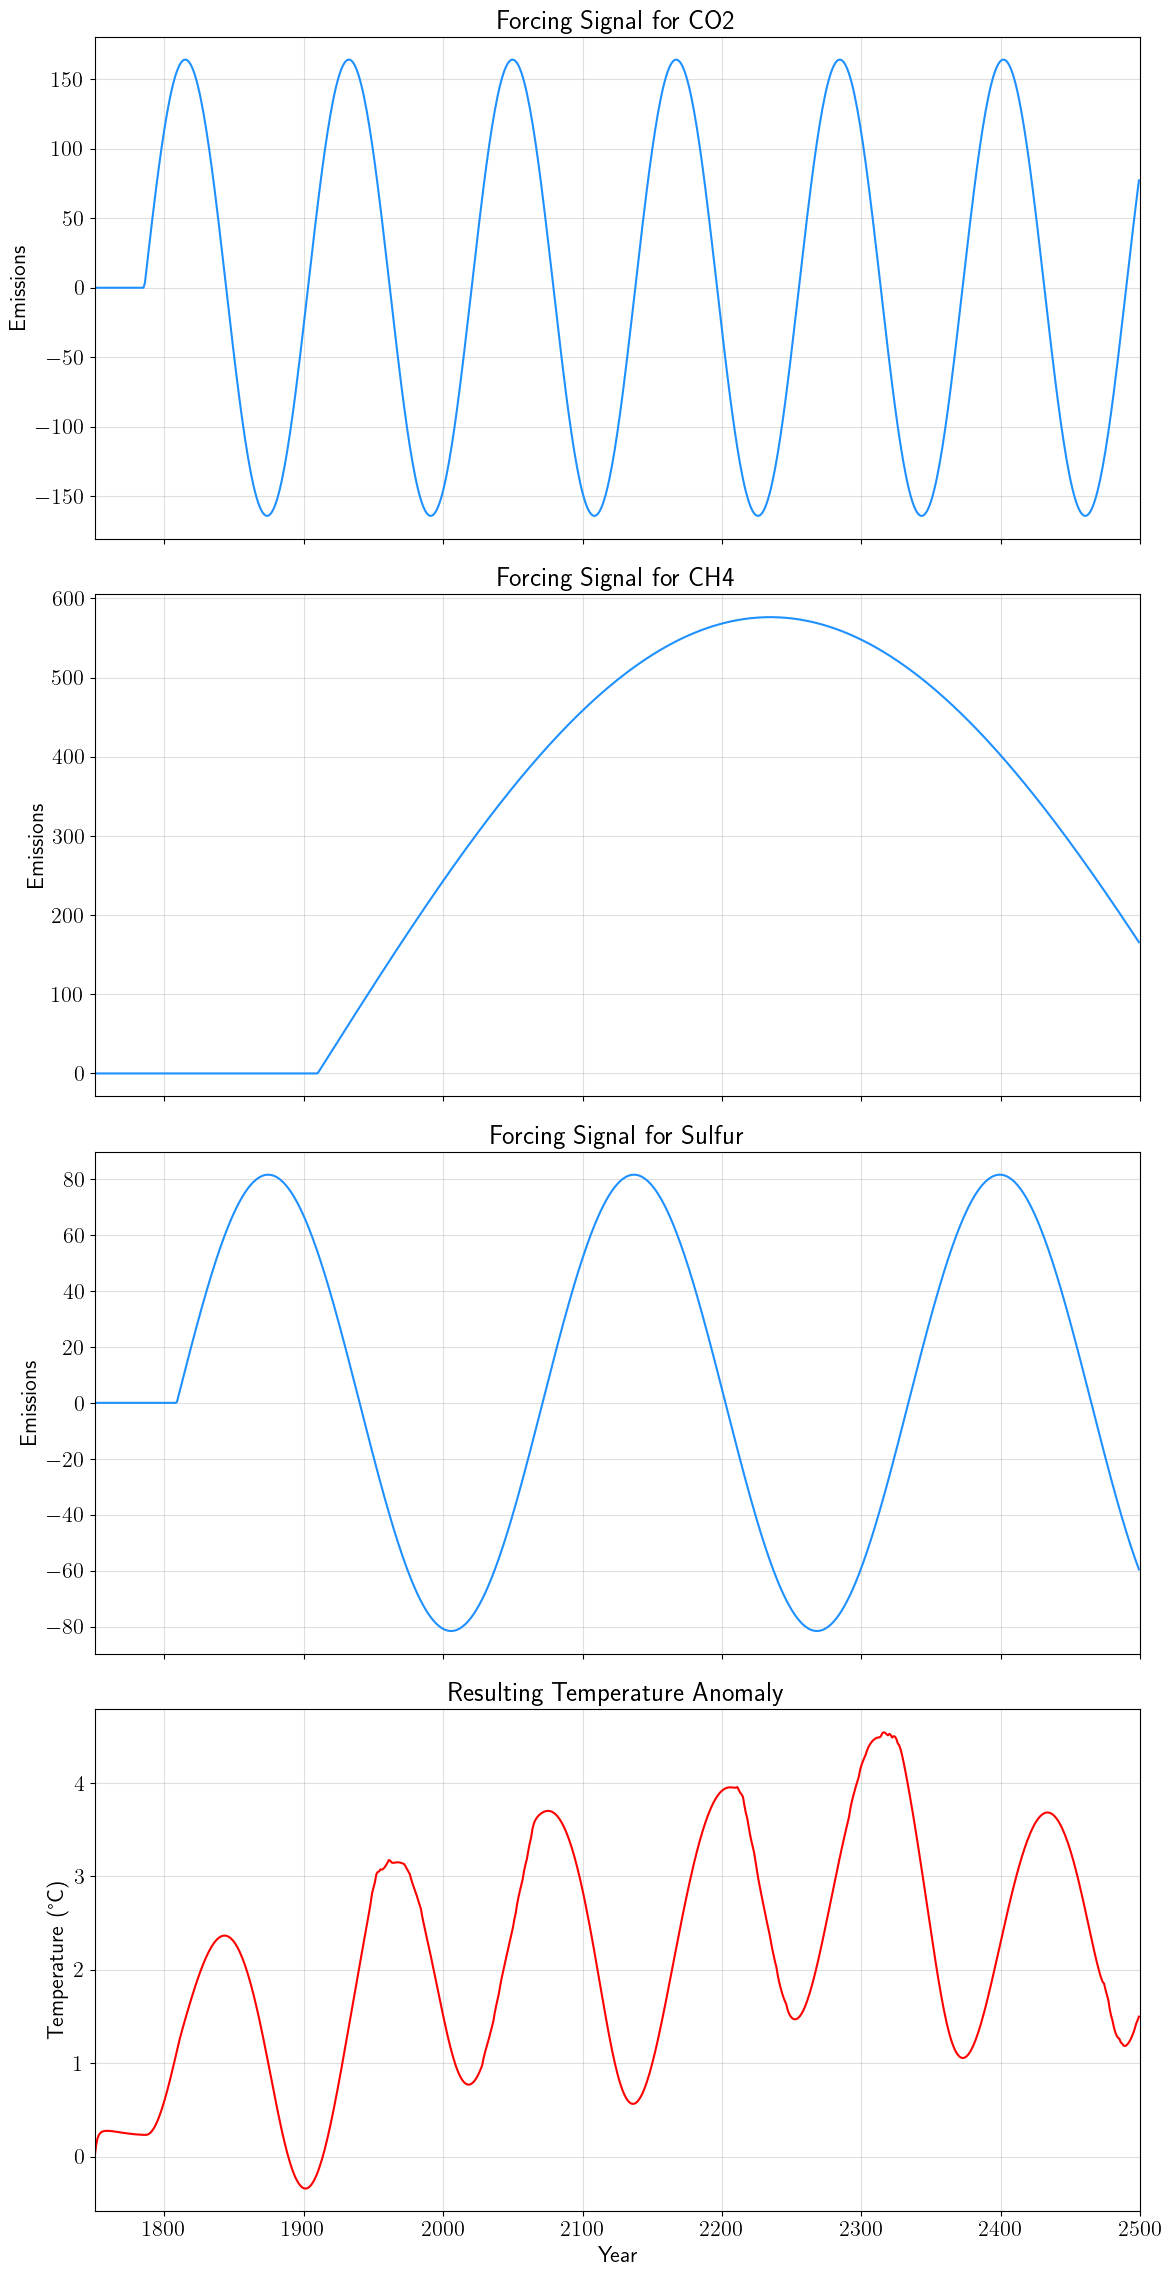

In [43]:
# Get best parameter combination
best_params = optimizer.max['params']
all_test_scenarios = scenarios_valid + scenarios_tier2
all_test_series = series_valid + series_tier2

# Plot optimal emissions
optimal_emissions, optimal_temp = utils_optimization.plot_optimal_signals(
  best_params=best_params,
  mean_func=mean_func,
  agents=AGENTS,
  n_steps=n_steps,
  FS=FS,
  start=start,
  stop=stop,
  CONFIG=CONFIG
)

Training and evaluation complete.


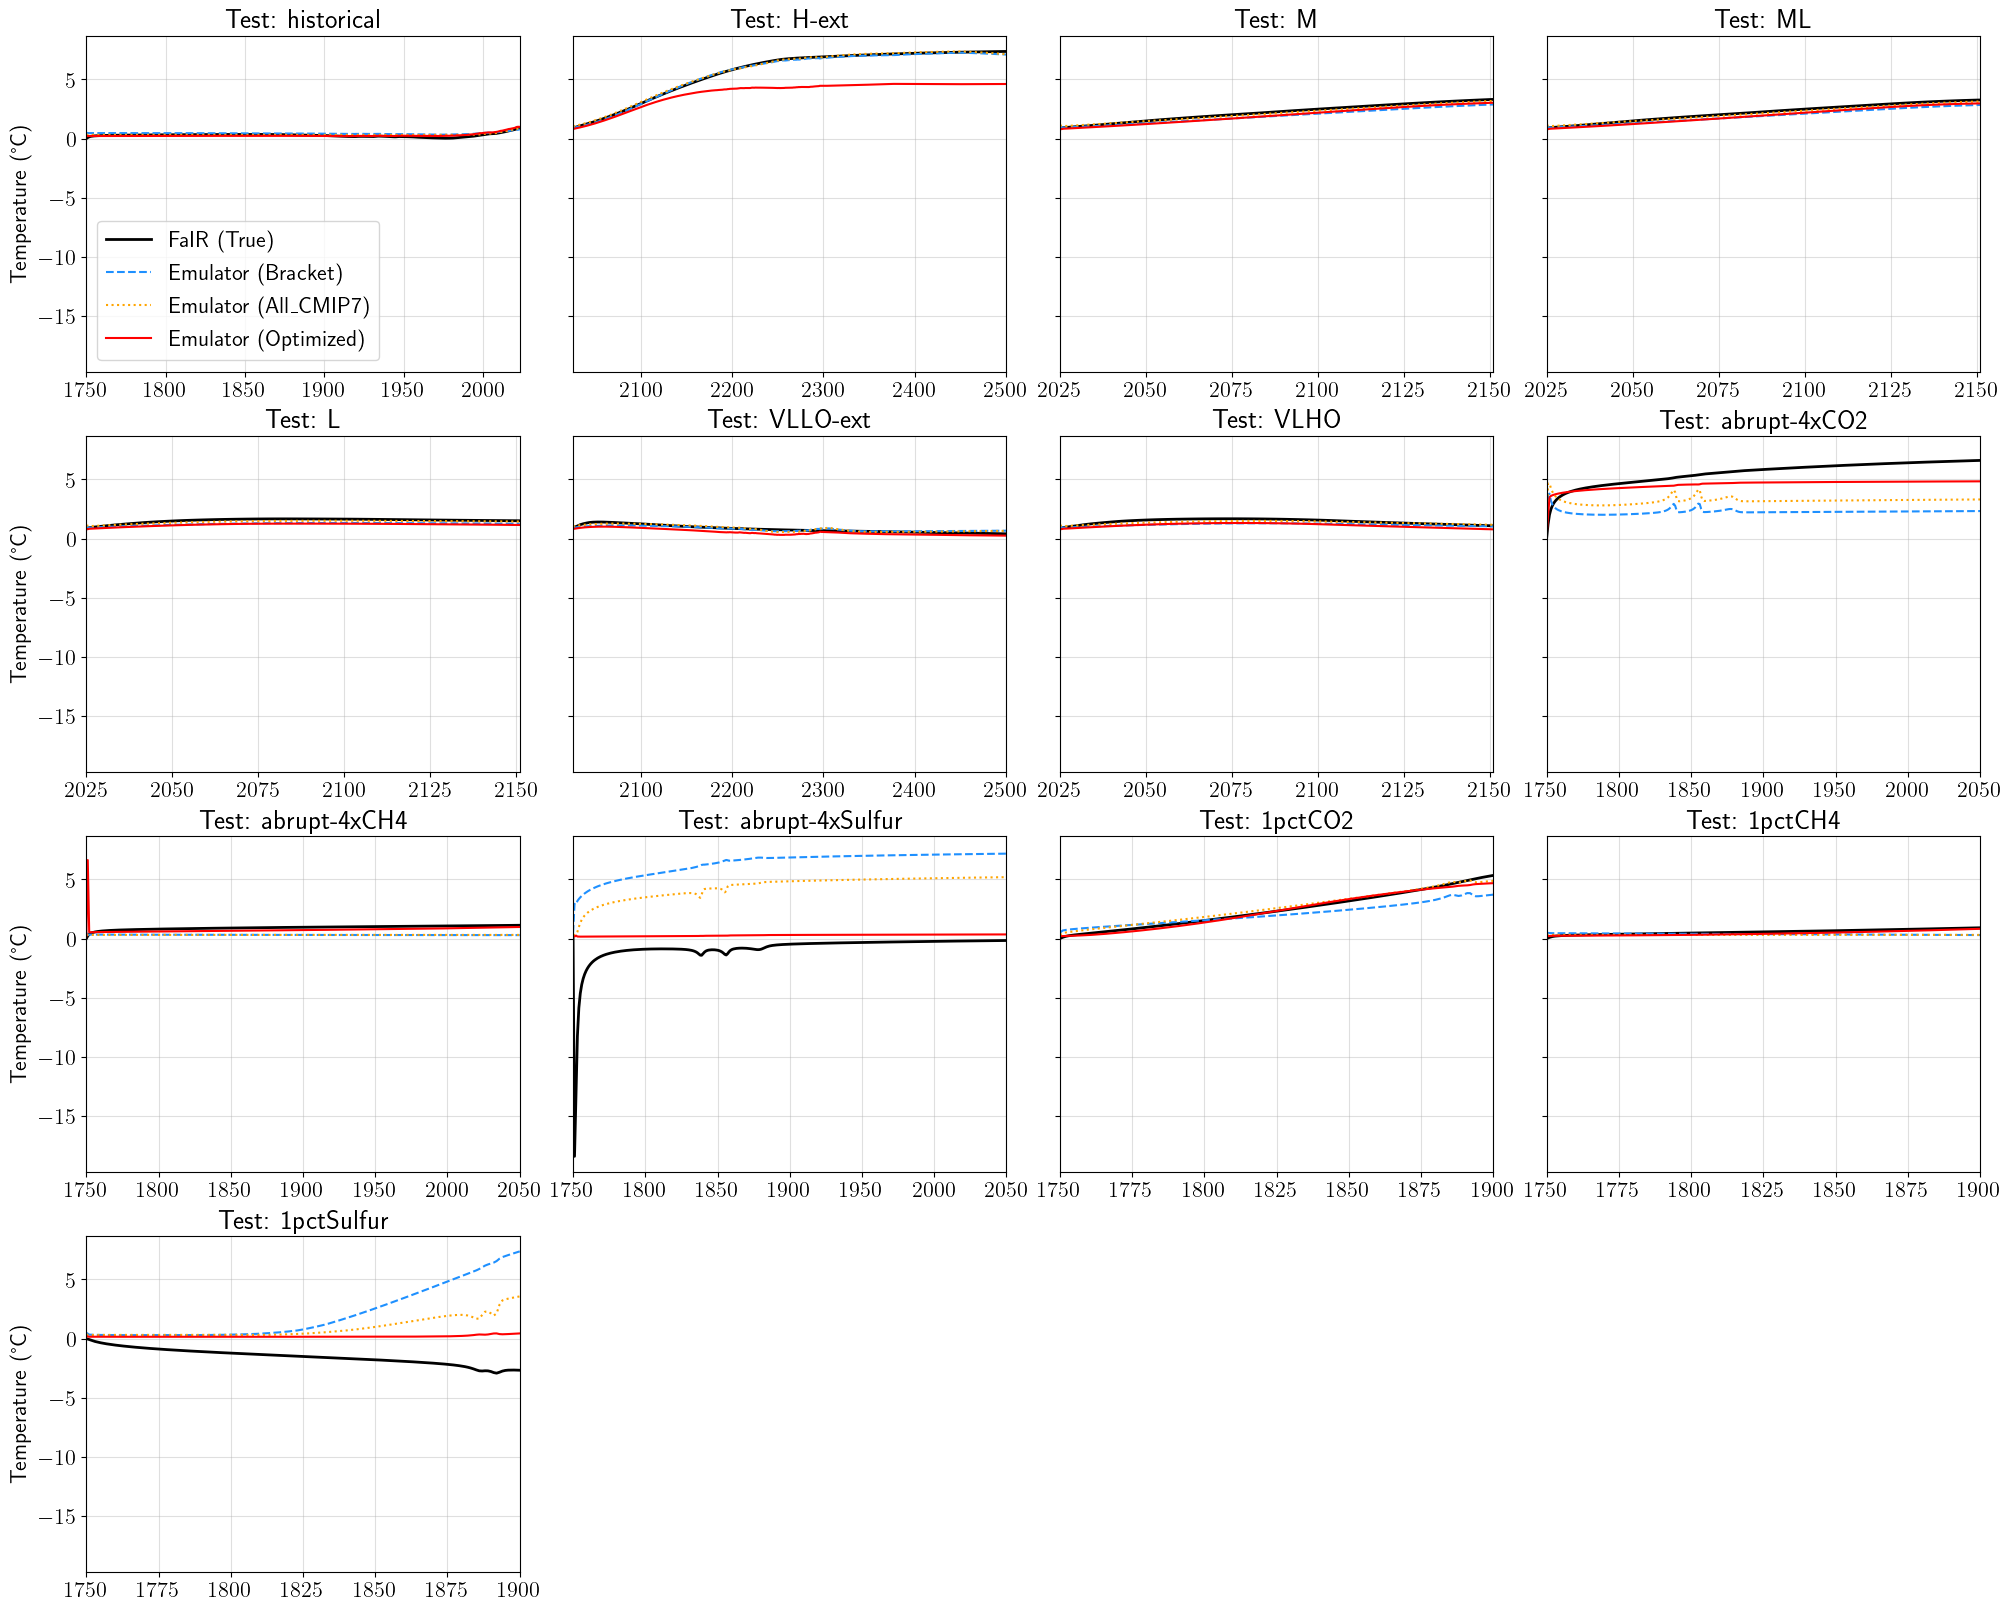

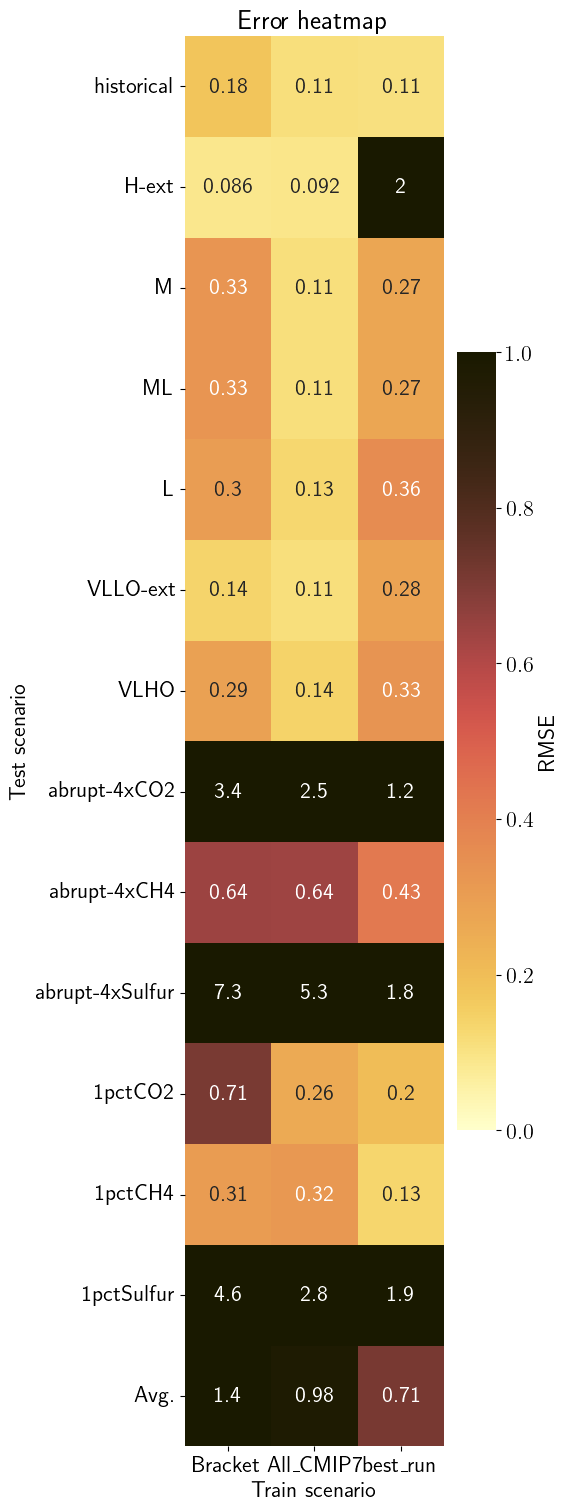

In [46]:
# Evaluate on the validation data
error_dict, yhat_dict, scenarios_train_all = utils_optimization.full_evaluation(
  emissions_dict_opt=optimal_emissions,
  delT_opt=optimal_temp,
  scenarios_tier1=scenarios_tier1,
  series_tier1=series_tier1,
  test_scenarios=scenarios_valid,
  test_series=series_valid,
  agents=AGENTS,
)

utils_optimization.plot_emulator_performance_grid(
  yhat_dict=yhat_dict,
  scenarios_train=scenarios_train_all,
  scenarios_test=scenarios_valid,
  series_test=series_valid,
  start=start
)

utils_ML.plot_error_heatmap(
  error_dict=error_dict,
  train_scenarios=scenarios_train_all,
  test_scenarios=scenarios_valid
)

In [51]:
import pickle
import numpy as np

checkpoint_path = "checkpoints/inverse_allsets.pkl"

def _tree_to_numpy(x):
    """Recursively convert any array-like leaves to np.ndarray, keep others."""
    # Fast path for dict / list / tuple
    if isinstance(x, dict):
        return {k: _tree_to_numpy(v) for k, v in x.items()}
    if isinstance(x, list):
        return [_tree_to_numpy(v) for v in x]
    if isinstance(x, tuple):
        return tuple(_tree_to_numpy(v) for v in x)

    # Anything that behaves like an array -> np.asarray
    # (covers JAX DeviceArray, jnp.ndarray, numpy arrays, etc.)
    try:
        return np.asarray(x)
    except Exception:
        # Non-array leaves (ints, strings, Optax state objects, etc.)
        return x

def load_inverse_ckpt_numpy(path):
    with open(path, "rb") as f:
        raw = pickle.load(f)

    out = {
        "U_traj": [_tree_to_numpy(u) for u in raw["U_traj"]],
        "errors": np.asarray(raw["errors"], dtype=np.float32),
        # Optax state is JAX-specific; convert any arrays inside, otherwise keep as-is.
        # If you won't use it outside JAX, set to None instead.
        "opt_state": _tree_to_numpy(raw.get("opt_state")),
        "step_count": int(raw["step_count"]),
        "time_weights": None if raw.get("time_weights") is None else _tree_to_numpy(raw["time_weights"]),
        "meta": raw.get("meta", {}),
    }
    return out

# Usage
ckpt = load_inverse_ckpt_numpy(checkpoint_path)
U_traj = ckpt["U_traj"]           # list of np arrays (or trees of np arrays)
errors = ckpt["errors"]           # np.ndarray
U = U_traj[-1]                    # last trajectory (np array / tree of np arrays)
opt_state = ckpt["opt_state"]     # converted where possible; may still be a nested object
updates_done = ckpt["step_count"]

emis_dict_inverse = {'CO2': U_traj[-1] + 3.5}

f_train = run_fair.build_fair(start, stop)
run_fair.set_emissions(f_train, years, run_fair.ensure_all_agents(emis_dict_inverse, n_steps))
f_train.run(progress=False)
_, _, training_temp, _ = run_fair.run_fair(f_train, years)

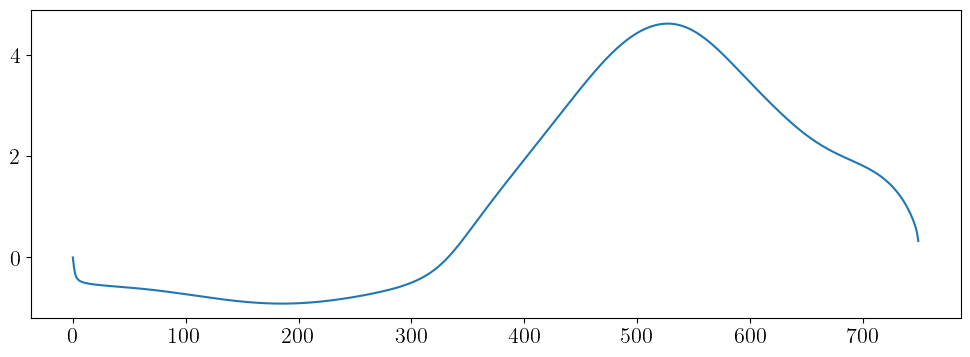

In [52]:
plt.plot(training_temp)

Training and evaluation complete.


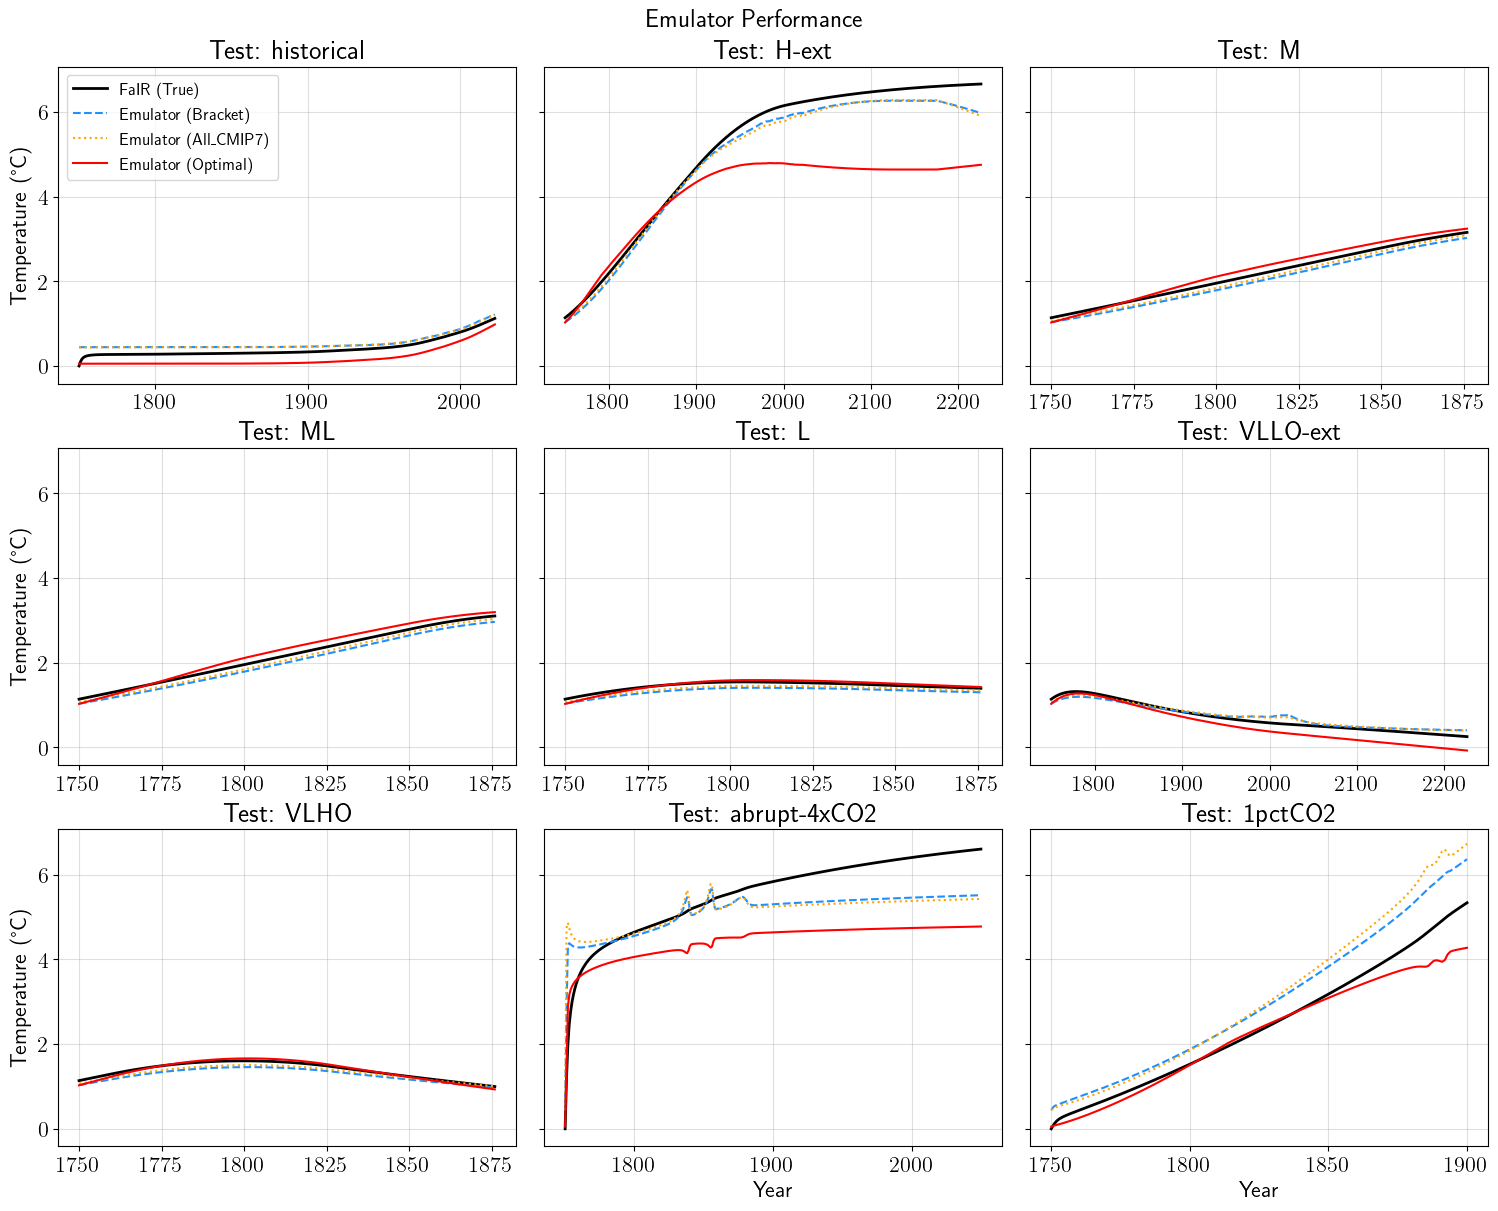

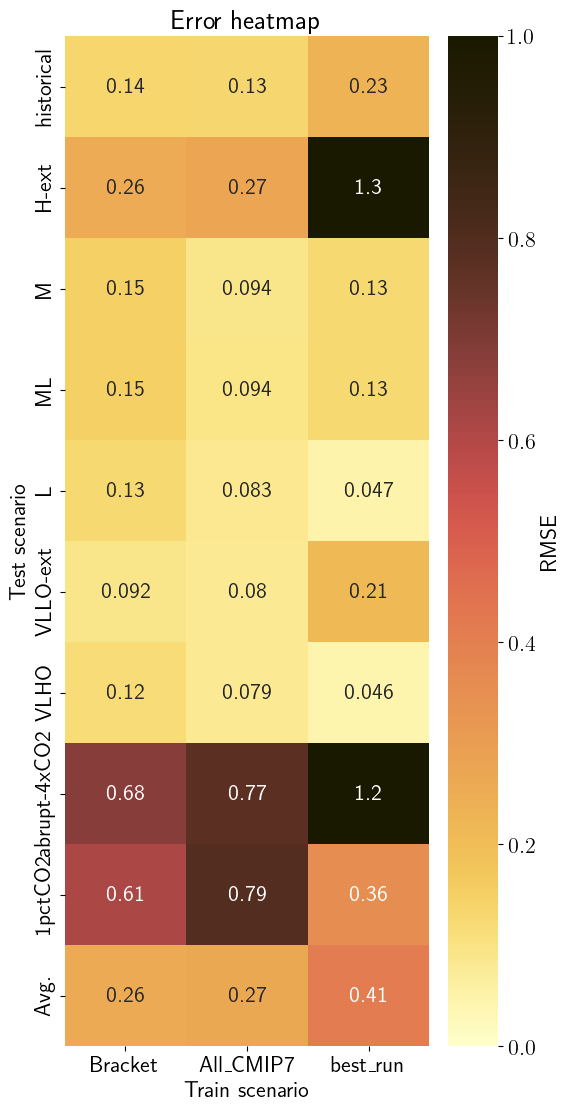

In [53]:
# Evaluate on the validation data
error_dict, yhat_dict, scenarios_train_all = utils_optimization.full_evaluation(
  emissions_dict_opt=emis_dict_inverse,
  delT_opt=training_temp,
  scenarios_tier1=scenarios_tier1,
  series_tier1=series_tier1,
  test_scenarios=scenarios_valid,
  test_series=series_valid,
  agents=AGENTS,
)

utils_optimization.plot_emulator_performance_grid(
  yhat_dict=yhat_dict,
  scenarios_train=scenarios_train_all,
  scenarios_test=scenarios_valid,
  series_test=series_valid,
  start=start
)

utils_ML.plot_error_heatmap(
  error_dict=error_dict,
  train_scenarios=scenarios_train_all,
  test_scenarios=scenarios_valid
)

Training and evaluation complete.


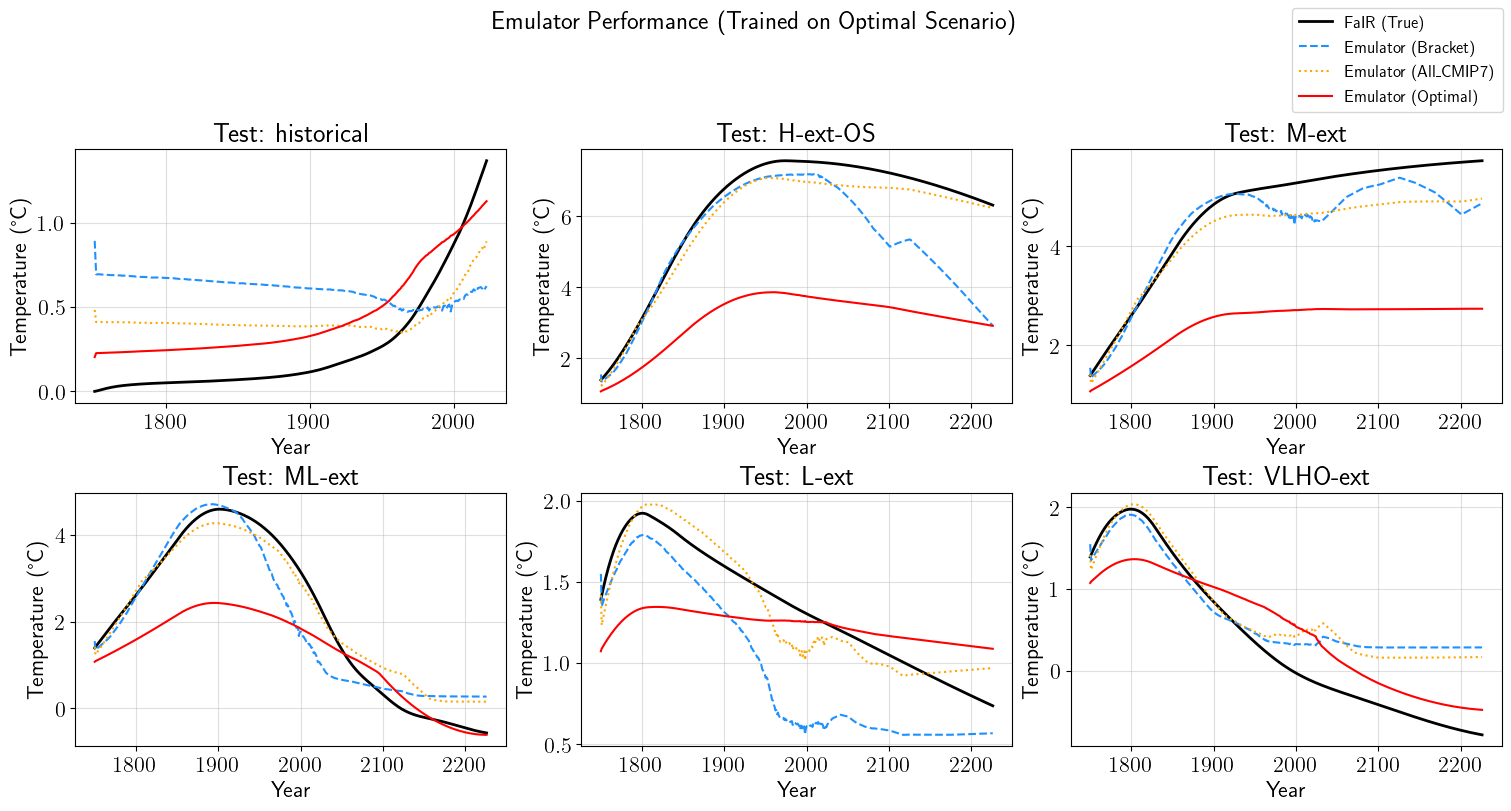

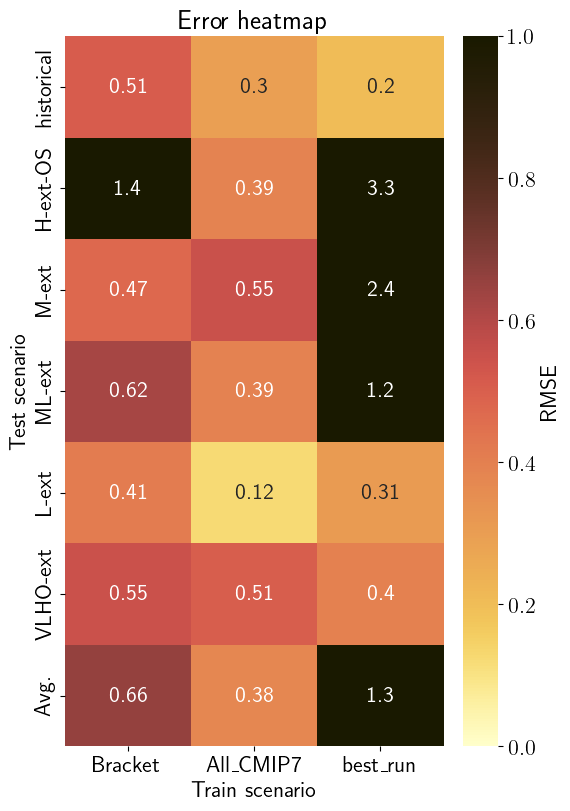

In [17]:
# Evaluate on the test data
error_dict, yhat_dict, scenarios_train_all = utils_optimization.full_evaluation(
  emissions_dict_opt=optimal_emissions,
  delT_opt=optimal_temp,
  scenarios_tier1=scenarios_tier1,
  series_tier1=series_tier1,
  test_scenarios=scenarios_tier2,
  test_series=series_tier2,
  agents=AGENTS,
)

utils_optimization.plot_emulator_performance_grid(
  yhat_dict=yhat_dict,
  scenarios_train=scenarios_train_all,
  scenarios_test=scenarios_tier2,
  series_test=series_tier2,
  start=start
)

utils_ML.plot_error_heatmap(
  error_dict=error_dict,
  train_scenarios=scenarios_train_all,
  test_scenarios=scenarios_tier2
)

Training and evaluation complete.


KeyError: 'CT'

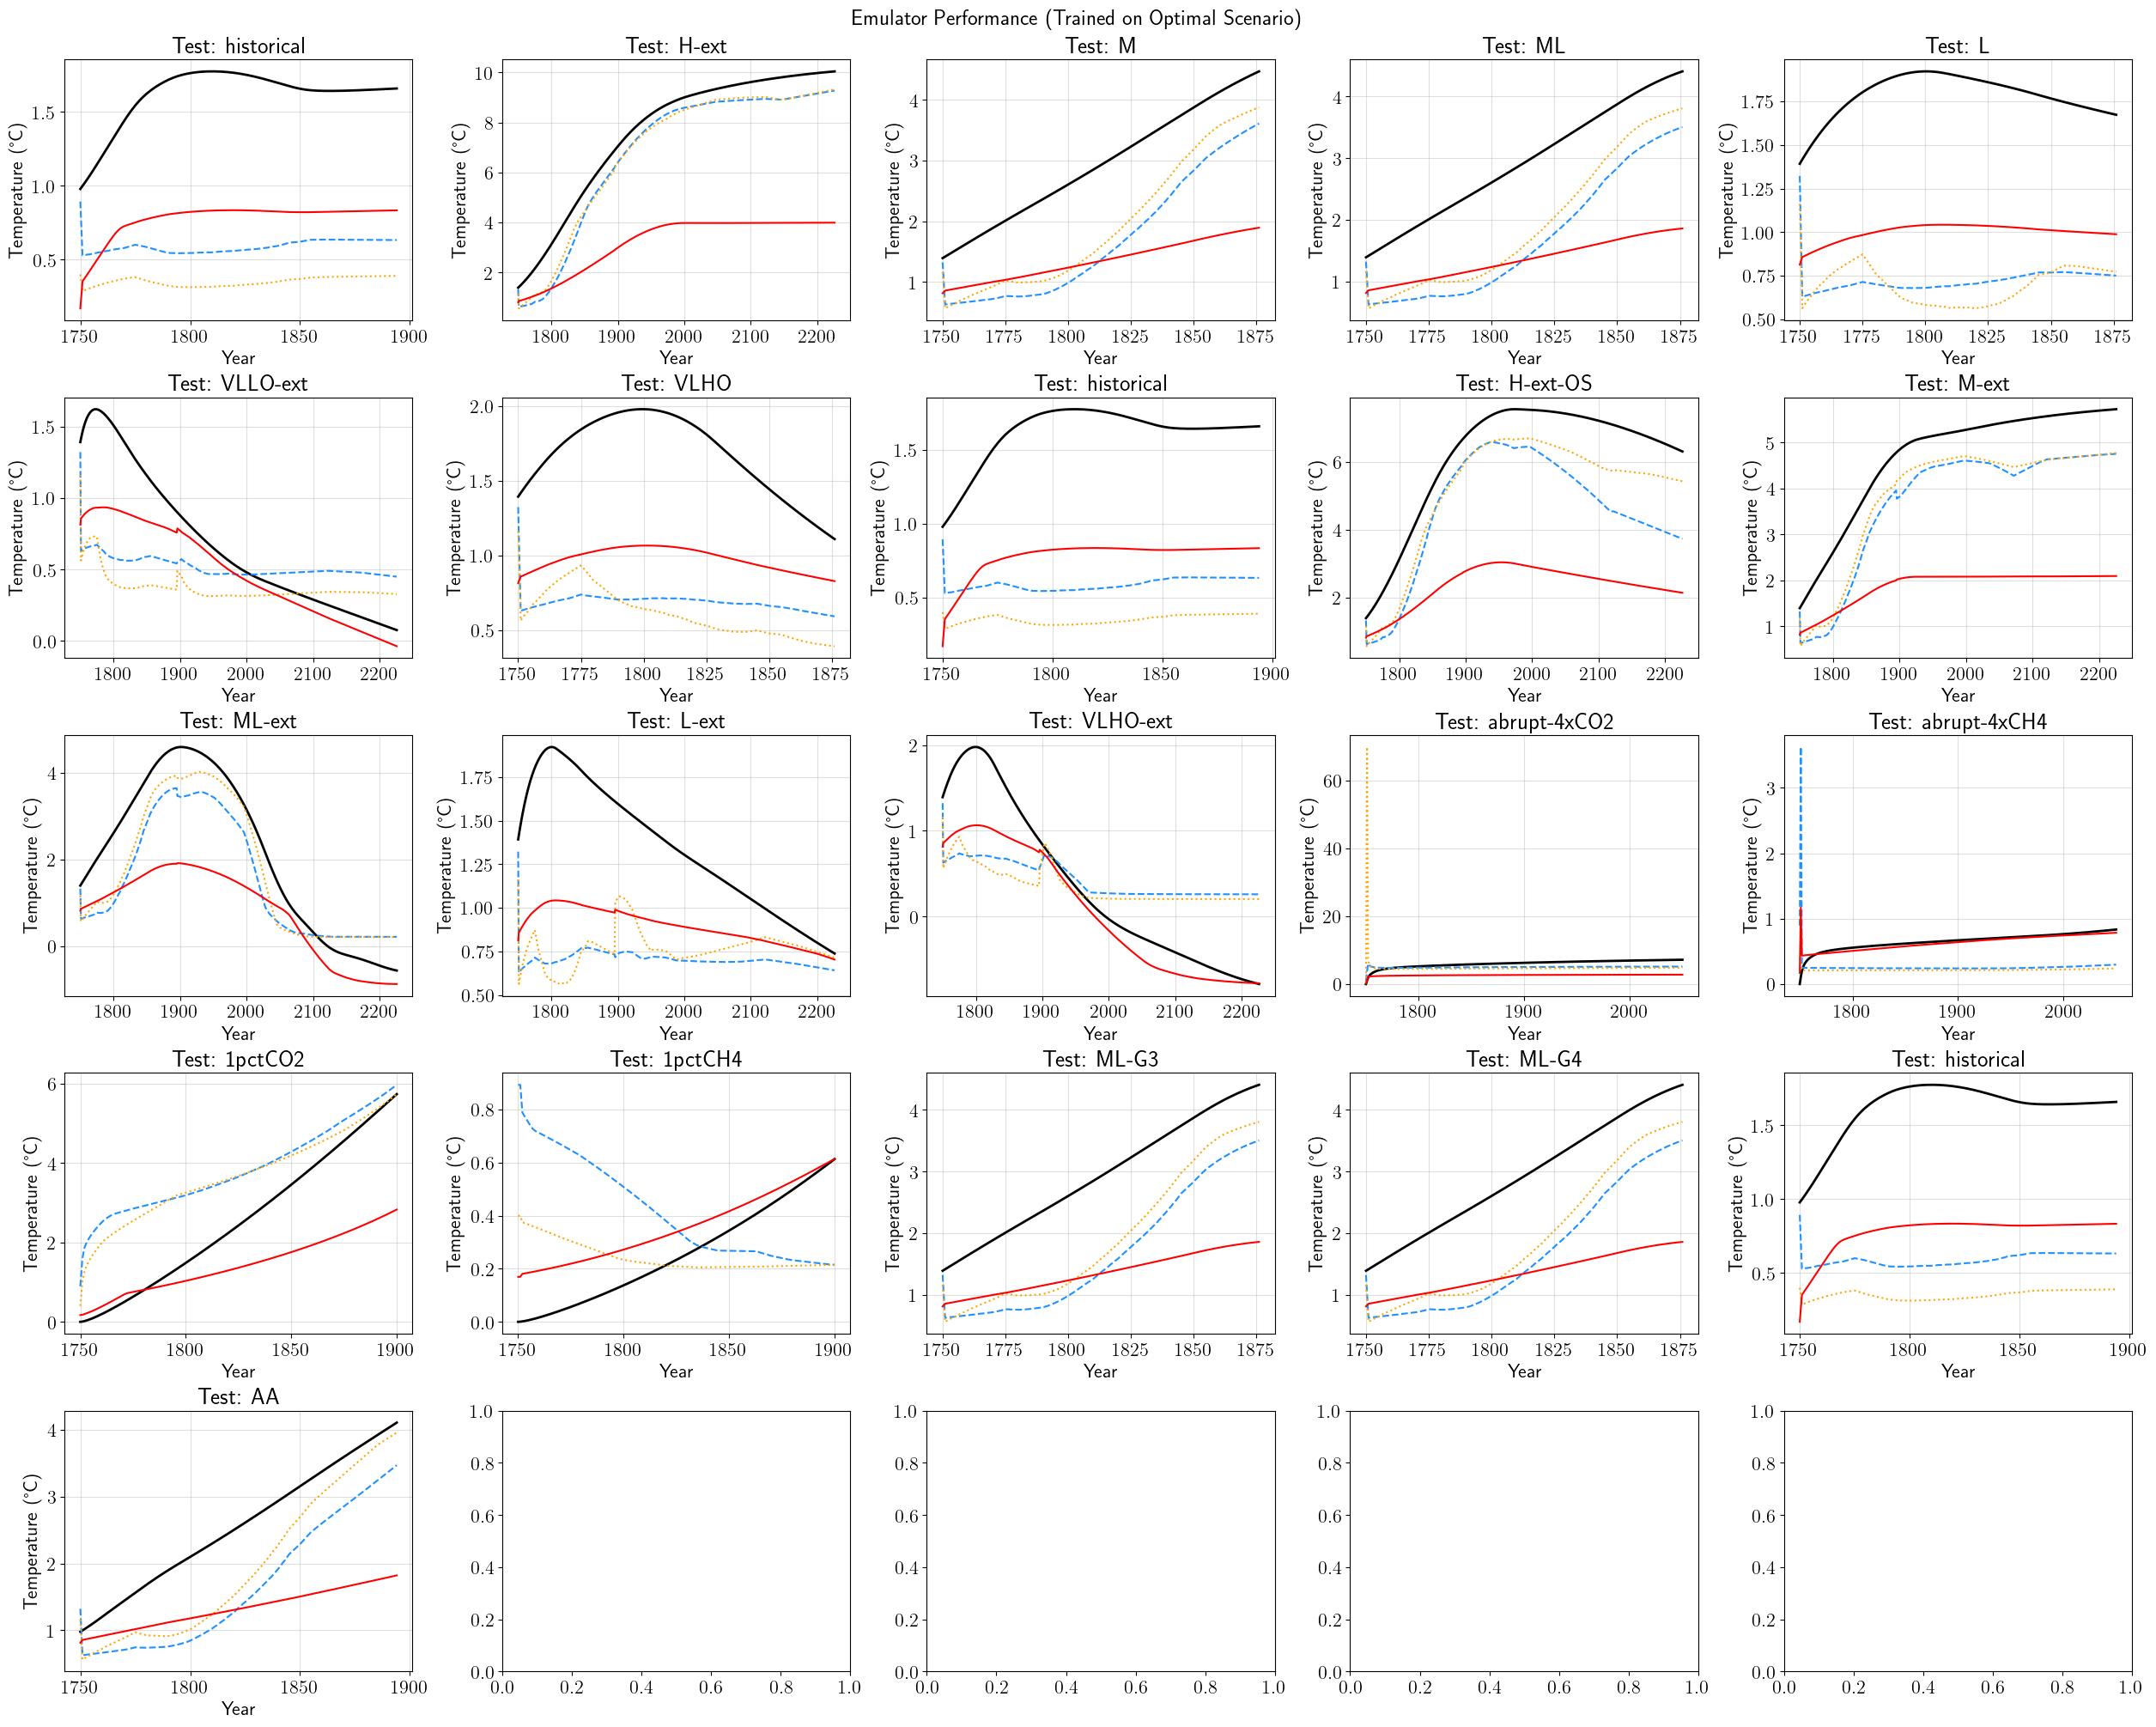

In [24]:
# Evaluate on all scenarios
error_dict, yhat_dict, scenarios_train_all = utils_optimization.full_evaluation(
  emissions_dict_opt=optimal_emissions,
  delT_opt=optimal_temp,
  scenarios_tier1=scenarios_tier1,
  series_tier1=series_tier1,
  test_scenarios=scenarios_all,
  test_series=series_all,
  agents=AGENTS,
)

utils_optimization.plot_emulator_performance_grid(
  yhat_dict=yhat_dict,
  scenarios_train=scenarios_train_all,
  scenarios_test=scenarios_all,
  series_test=series_all,
  start=start
)

utils_ML.plot_error_heatmap(
  error_dict=error_dict,
  train_scenarios=scenarios_train_all,
  test_scenarios=scenarios_all
)